In [21]:
import os
import glob
import numpy as np
import rasterio
import datetime as dt
from dateutil import tz
import sys
sys.path.append(r"C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like")
#from atmcor.atmospheric_parameters import ATMO_parameter
#from atmcor.cams_data_reader import ECMWF_Product
from atmcor.smac import smac
sys.path.append(r"C:\Users\SamanthaLavender\Documents\GitHub\sen2like\prisma4sen2like\prisma")
from sunpy.coordinates import sun
from spectral_aggregation_functions import radiance_to_reflectance


In [22]:
inpath = r"C:\DDrive\Vega\MOS\Radiometry"
tds = r"TDS1"
filename = r"MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858.TIFF"
infolder = os.path.join(inpath, tds, filename)
files = glob.glob(os.path.join(infolder,"MO*_B*.TIF"))
print("Found: {}".format(files))

Found: ['C:\\DDrive\\Vega\\MOS\\Radiometry\\TDS1\\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858.TIFF\\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858_B1.TIF', 'C:\\DDrive\\Vega\\MOS\\Radiometry\\TDS1\\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858.TIFF\\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858_B2.TIF', 'C:\\DDrive\\Vega\\MOS\\Radiometry\\TDS1\\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858.TIFF\\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858_B3.TIF', 'C:\\DDrive\\Vega\\MOS\\Radiometry\\TDS1\\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858.TIFF\\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858_B4.TIF']


In [23]:
# Load band data
nbands = len(files)
# Using Landsat 5TM bands while MSS Coeffs generated
bands = ['b1','b2','b3','b4']
offset = [19.758, 25.208, 40.386, 45.345]
gain = [1.051, 0.918, 0.902, 0.669]
for i,file in enumerate(files):
    ds = rasterio.open(file)
    if i == 0:
        print("Dataset: {}".format(ds.shape))
        img = np.zeros((nbands,ds.shape[0],ds.shape[1]), dtype = np.float32)
    img[i,:,:] = (ds.read().astype(np.float32) * gain[i]) + offset[i]
    ds.close()
print("Read in data and applied scaling to radiance: {} {}".format(np.nanmin(img),np.nanmax(img)))

Dataset: (2439, 2351)
Read in data and applied scaling to radiance: 19.757999420166016 98.11399841308594


In [24]:
# from XML file
## Solar zenith and azimuth angles
theta_s = np.deg2rad(18.947148)
phi_s = np.deg2rad(107.586944)

# View Zenith and Azimuth Angles
theta_v = np.deg2rad(90.0 - 31.866694)   
phi_v = np.deg2rad(171.880692)  

In [25]:
# default params
uH2O = 2.0  # Water Vapor content - unit: g.cm-2
uO3 = 0.331  # Ozone content - unit: cm-atm , 0.3 cm-atm = 300 Dobson Units
pressure = 1013.095  # Pressure - unit: hpa
taup550 = 0.2  # taup550 - unit: unitless


In [26]:
# Convert to TOA reflectance
## from radiance (W.m-2.sr-1.nm-1) to reflectance (unitless)
#ESUN from Chander et al. 2009 from Landsat 4MSS W.m-2.um
esun = np.array([1823., 1559., 1279., 800.1])# / 1000.0   
start_time = dt.datetime(1990, 6, 19, 9, 30, 41).replace(tzinfo=tz.tzutc())
sun_earth_distance = sun.earth_distance(start_time).value
print("Sun Earth Distance: {:.3f}".format(sun_earth_distance))
rtoaimg = np.zeros((nbands,ds.shape[0],ds.shape[1]), dtype = np.float32)
for b in range(nbands):
    rtoaimg[b,:,:] = radiance_to_reflectance(img[b,:,:], esun[b], theta_s, sun_earth_distance)
    print("band {} TOA reflectance: {:.3f} {:.3f}".format(b+1,np.nanmin(rtoaimg[b,:,:]),np.nanmax(rtoaimg[b,:,:])))

Sun Earth Distance: 1.016
band 1 TOA reflectance: 0.035 0.155
band 2 TOA reflectance: 0.052 0.173
band 3 TOA reflectance: 0.102 0.249
band 4 TOA reflectance: 0.184 0.347


In [27]:
def get_smac_coefficients(sensor,band):
    # format e.g. Coef_MSS5_CONT_B2
    filename = "Coef_{}_CONT_{}.dat".format(sensor,band)
    if filename is None:
        return None

    # smac coefficient are in the smac package
    smac_directory = os.path.dirname(os.path.abspath(smac.__file__))
    smac_file = os.path.join(smac_directory, 'COEFS', filename)
    if os.path.exists(smac_file):
        return smac_file
    else:
        print("Could not find {}".format(smac_file))
        return None

In [28]:
# Atmospheric parameters retrieve from CAMS :
r_toa = np.arange(101) / 100.
r_surf_SMAC = np.zeros(101)

# # Apply correction
sensor = "MSS5"
rboaimg = np.zeros((nbands,ds.shape[0],ds.shape[1]), dtype = np.float32)
for b,band in enumerate(bands):
    print("Processing band {} {}".format(b,band))
    # Load SMAC coefficients
    coef_file = get_smac_coefficients(sensor, band)
    print(coef_file)
    if coef_file is None:
        raise SystemExit("No smac coefficients for %s", band)
    smac_coefs = smac.coeff(coef_file)

    # Run SMAC for r_toa ranging from 0.0 to 1.0
    for i in range(101):
        r_surf_SMAC[i] = smac.smac_inv(
            r_toa[i], theta_s, phi_s,
            theta_v, phi_v, pressure,
            taup550, uO3, uH2O, smac_coefs)
    #
    # Use a polynomial fit of order 2 to fit relation between surface reflectance and TOA reflectance
    poly_coefs = np.polyfit(r_toa, r_surf_SMAC, 2, full=True)
    if b == 0:
        print("Coeffs: {}".format(poly_coefs))
    
    # Apply fitted relation to convert TOA reflectance to surface reflectance
    sref = poly_coefs[0][2] + poly_coefs[0][1] * rtoaimg[b,:,:] + poly_coefs[0][0] * rtoaimg[b,:,:] ** 2
    mask = (rtoaimg[b,:,:] <= 0)
    mask2 = (sref <= 0)
    sref[mask] = 0
    sref[mask2] = 0
    rboaimg[b,:,:] = sref[:,:]
    print("band {} BOA reflectance: {:.3f} {:.3f}".format(b+1,np.nanmin(rboaimg[b,:,:]),np.nanmax(rboaimg[b,:,:])))


Processing band 0 b1
C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like\atmcor\smac\COEFS\Coef_MSS5_CONT_b1.dat
Coeffs: (array([-0.16407622,  1.29179631, -0.06593172]), array([2.18199841e-05]), np.int32(3), array([1.64934844, 0.51943226, 0.09919601]), np.float64(2.2426505097428162e-14))
band 1 BOA reflectance: 0.000 0.130
Processing band 1 b2
C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like\atmcor\smac\COEFS\Coef_MSS5_CONT_b2.dat
band 2 BOA reflectance: 0.026 0.169
Processing band 2 b3
C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like\atmcor\smac\COEFS\Coef_MSS5_CONT_b3.dat
band 3 BOA reflectance: 0.100 0.273
Processing band 3 b4
C:\Users\SamanthaLavender\Documents\GitHub\sen2like\sen2like\sen2like\atmcor\smac\COEFS\Coef_MSS5_CONT_b4.dat
band 4 BOA reflectance: 0.235 0.450


In [29]:
# Save to Level 2 file
ofile = files[0].replace("B1.TIF","L2.TIF")
with rasterio.open(files[0]) as src:
    out_meta = src.meta
 
    # Change the band count and data format
    out_meta.update(dtype=rasterio.float32, count=nbands, nodata=0.0)

with rasterio.open(ofile, "w", **out_meta) as dest:
    for i in range(nbands):
        dest.write(rboaimg[i,:,:], i+1)

if os.path.exists(ofile):
    print("Success, generated {}".format(ofile))
else:
    raise SystemExit("Failed to generate L2 file")

Success, generated C:\DDrive\Vega\MOS\Radiometry\TDS1\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858.TIFF\MO01_MES_GEC_1P_19900619T093023_19900619T093041_MTI_16958_1858_L2.TIF


Plot written to: MESSR-spectra.png


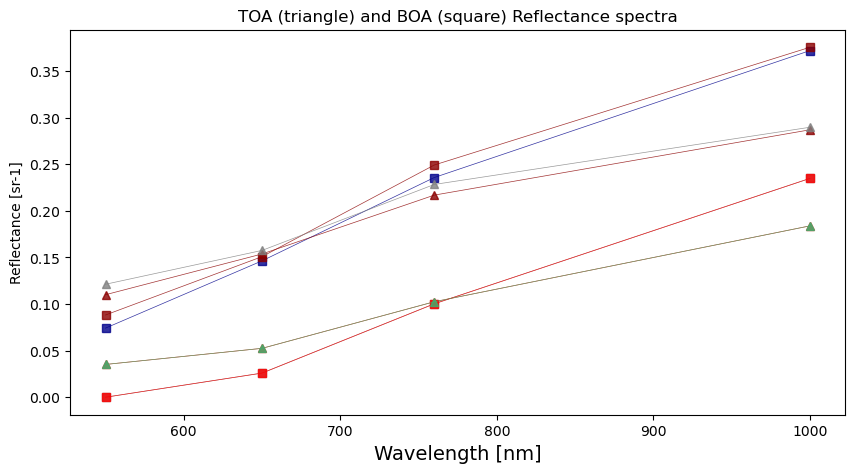

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
%matplotlib inline
ibands = [550.0,650.0,760.0,1000.0]

# Plot data
plt.figure(figsize=(10,5))
ax = plt.gca()
colorb = np.array(['darkblue','darkred','grey','red','mediumseagreen','blue','pink','darkgreen','teal','pink','cyan','purple','brown'])
pixels = [400,1400,2000,2300]
for i,pixel in enumerate(pixels):
    ax.plot(ibands, rboaimg[:,pixel,pixel], marker='s', color=colorb[i], lw=0.5, alpha=0.8)
    ax.plot(ibands, rtoaimg[:,pixel,pixel], marker='^', color=colorb[i+1], lw=0.5, alpha=0.8)
plt.title('TOA (triangle) and BOA (square) Reflectance spectra') 
plt.xlabel("Wavelength [nm]",size=14)
ax.set_ylabel("Reflectance [sr-1]")

outfig = 'MESSR-spectra.png'
plt.savefig(outfig, dpi=300, bbox_inches='tight')
print("Plot written to: {}".format(outfig))
plt.show()